In [7]:
from typing import Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import AnyMessage,AIMessage,BaseMessage
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt,Command
from dotenv import load_dotenv
from typing import TypedDict,Annotated


In [8]:
load_dotenv()

True

In [9]:
llm=ChatGroq(model="llama-3.3-70b-versatile")

In [10]:
from langgraph.graph.message import add_messages

class ChatState[TypedDict]:
    messages:Annotated[list[BaseMessage],add_messages]

In [11]:
def chat_node(state:ChatState):

    decision=interrupt({
        'type':'approval',
        'reason':'Model is about to answer user question',
        'question':state['messages'][-1].content,
        'instruction':'approve this question? yes/no'
    })

    if decision['approved']=='no':
        return{'messages' :[AIMessage(content="not approved")]}

    else:
        response = llm.invoke(state['messages'])
        return{'messages':[response]}

In [14]:
# build the graph

builder=StateGraph(ChatState)

builder.add_node('chat',chat_node)
builder.add_edge(START,'chat')
builder.add_edge('chat',END)

#check pointer is required
checkpointer=MemorySaver()

app=builder.compile(checkpointer=checkpointer)

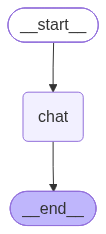

In [15]:
app

In [24]:
# create a new thread id
config={'configurable':{"thread_id":'1234'}}

# step-1 user ask question
initial_input={
    'messages':[
        ('user',"explain bag of words")
    ]
}

# invoke the graph
result=app.invoke(initial_input,config=config)

In [25]:
result

{'messages': [HumanMessage(content='explain bag of words', additional_kwargs={}, response_metadata={}, id='d975c672-d99f-43f2-aa25-3c86ca4dc27d'),
  AIMessage(content='**Introduction to Bag of Words**\n================================\n\nThe Bag of Words (BoW) is a fundamental concept in natural language processing (NLP) and information retrieval. It\'s a simple, yet effective way to represent text data as numerical vectors, enabling machine learning algorithms to process and analyze text.\n\n**What is Bag of Words?**\n------------------------\n\nThe Bag of Words model represents a text document as a bag, or a set, of its word occurrences without considering the order or grammar of the words. Each document is represented as a vector of word frequencies, where each element in the vector corresponds to the frequency of a particular word in the document.\n\n**How Does it Work?**\n--------------------\n\nHere\'s a step-by-step explanation of the Bag of Words process:\n\n1. **Tokenization**

In [26]:
message= result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer user question',
 'question': 'explain bag of words',
 'instruction': 'approve this question? yes/no'}

In [27]:
user_input=input(f"\nBackend message - {message} \n approve this question?(y/n): ")

In [28]:
# resume graph with user decision

final_result=app.invoke(\
    Command(resume={'approved': user_input}),
    config=config,
    )

In [29]:
print(final_result)

{'messages': [HumanMessage(content='explain bag of words', additional_kwargs={}, response_metadata={}, id='d975c672-d99f-43f2-aa25-3c86ca4dc27d'), AIMessage(content='**Introduction to Bag of Words**\n================================\n\nThe Bag of Words (BoW) is a fundamental concept in natural language processing (NLP) and information retrieval. It\'s a simple, yet effective way to represent text data as numerical vectors, enabling machine learning algorithms to process and analyze text.\n\n**What is Bag of Words?**\n------------------------\n\nThe Bag of Words model represents a text document as a bag, or a set, of its word occurrences without considering the order or grammar of the words. Each document is represented as a vector of word frequencies, where each element in the vector corresponds to the frequency of a particular word in the document.\n\n**How Does it Work?**\n--------------------\n\nHere\'s a step-by-step explanation of the Bag of Words process:\n\n1. **Tokenization**: 